C:\Users\Aayush\AppData\Local\Temp\ipykernel_19244\2030038027.py:5: DtypeWarning: Columns (1,8) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("your_dataset.csv")


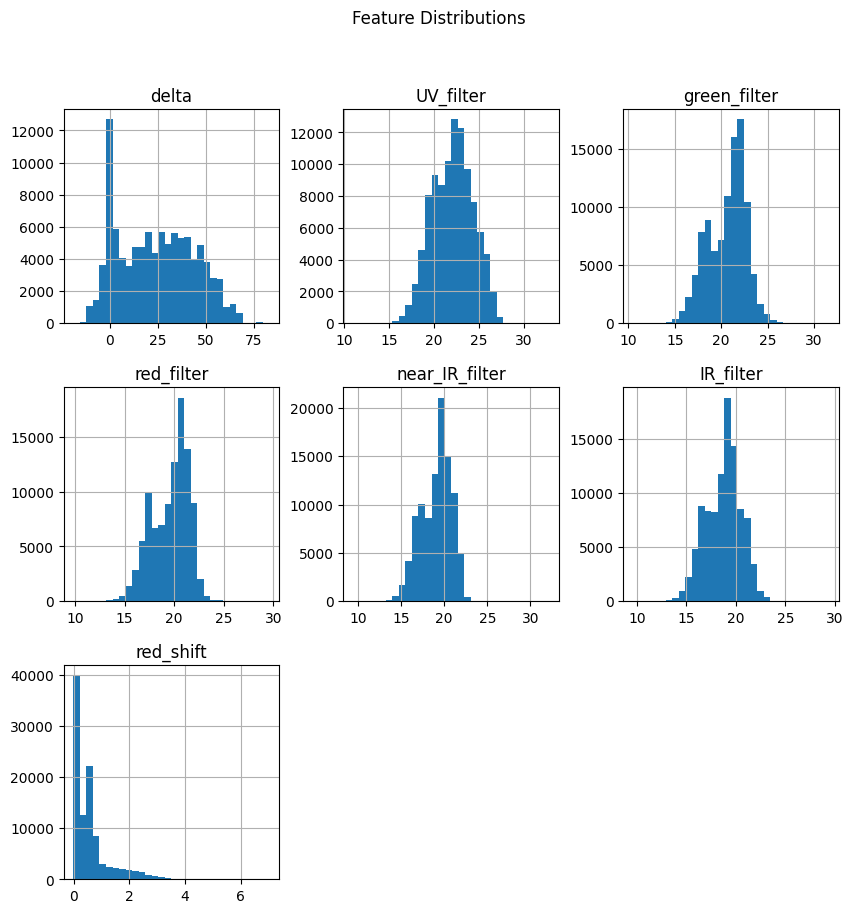

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("your_dataset.csv")

df.drop(columns=['object_ID'], errors='ignore', inplace=True)

df.replace(r'^\s*$', np.nan, regex=True, inplace=True)
df.replace(-9999, np.nan, inplace=True)

drop_cols = [
    'run_ID','rerun_ID','cam_col','field_ID',
    'plate_ID','MJD','fiber_ID','spec_obj_ID'
]
df.drop(columns=drop_cols, errors='ignore', inplace=True)

y = df['class']
X = df.drop(columns=['class']).select_dtypes(include=[np.number])

X = X.dropna()
y = y.loc[X.index]

X.hist(figsize=(10,10), bins=30)
plt.suptitle("Feature Distributions")
plt.show()

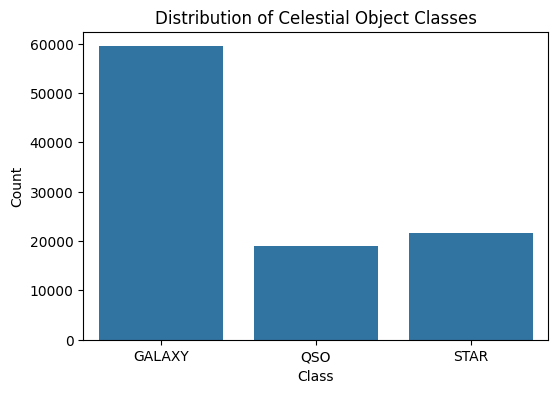

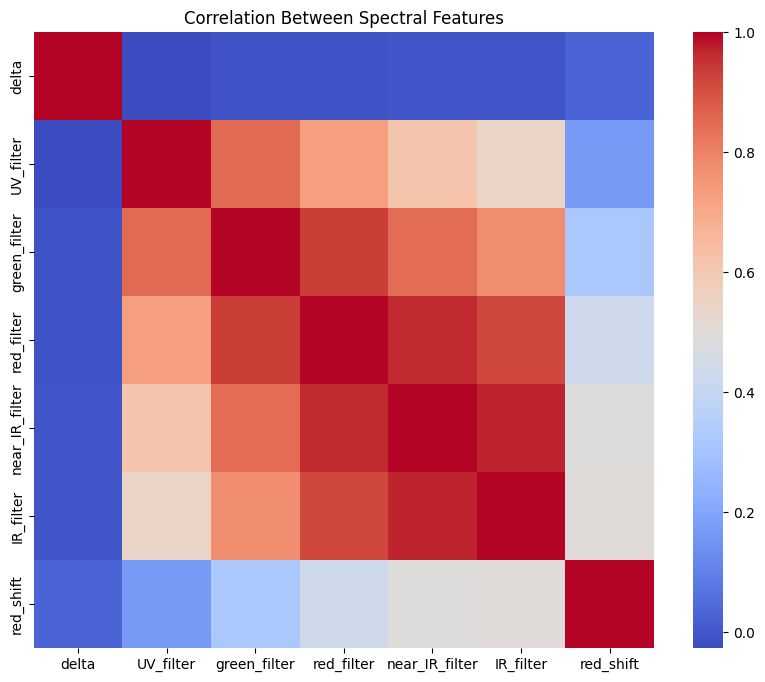

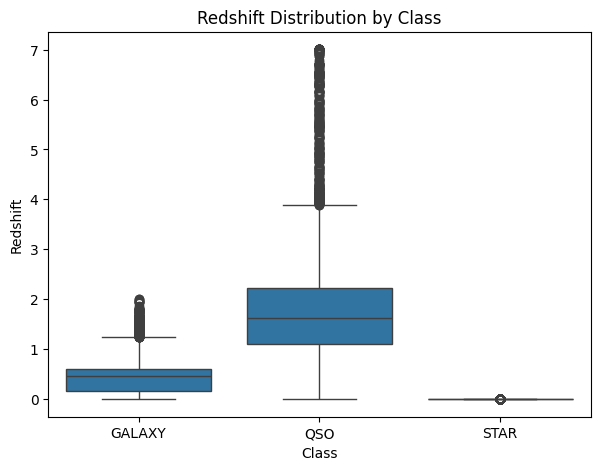

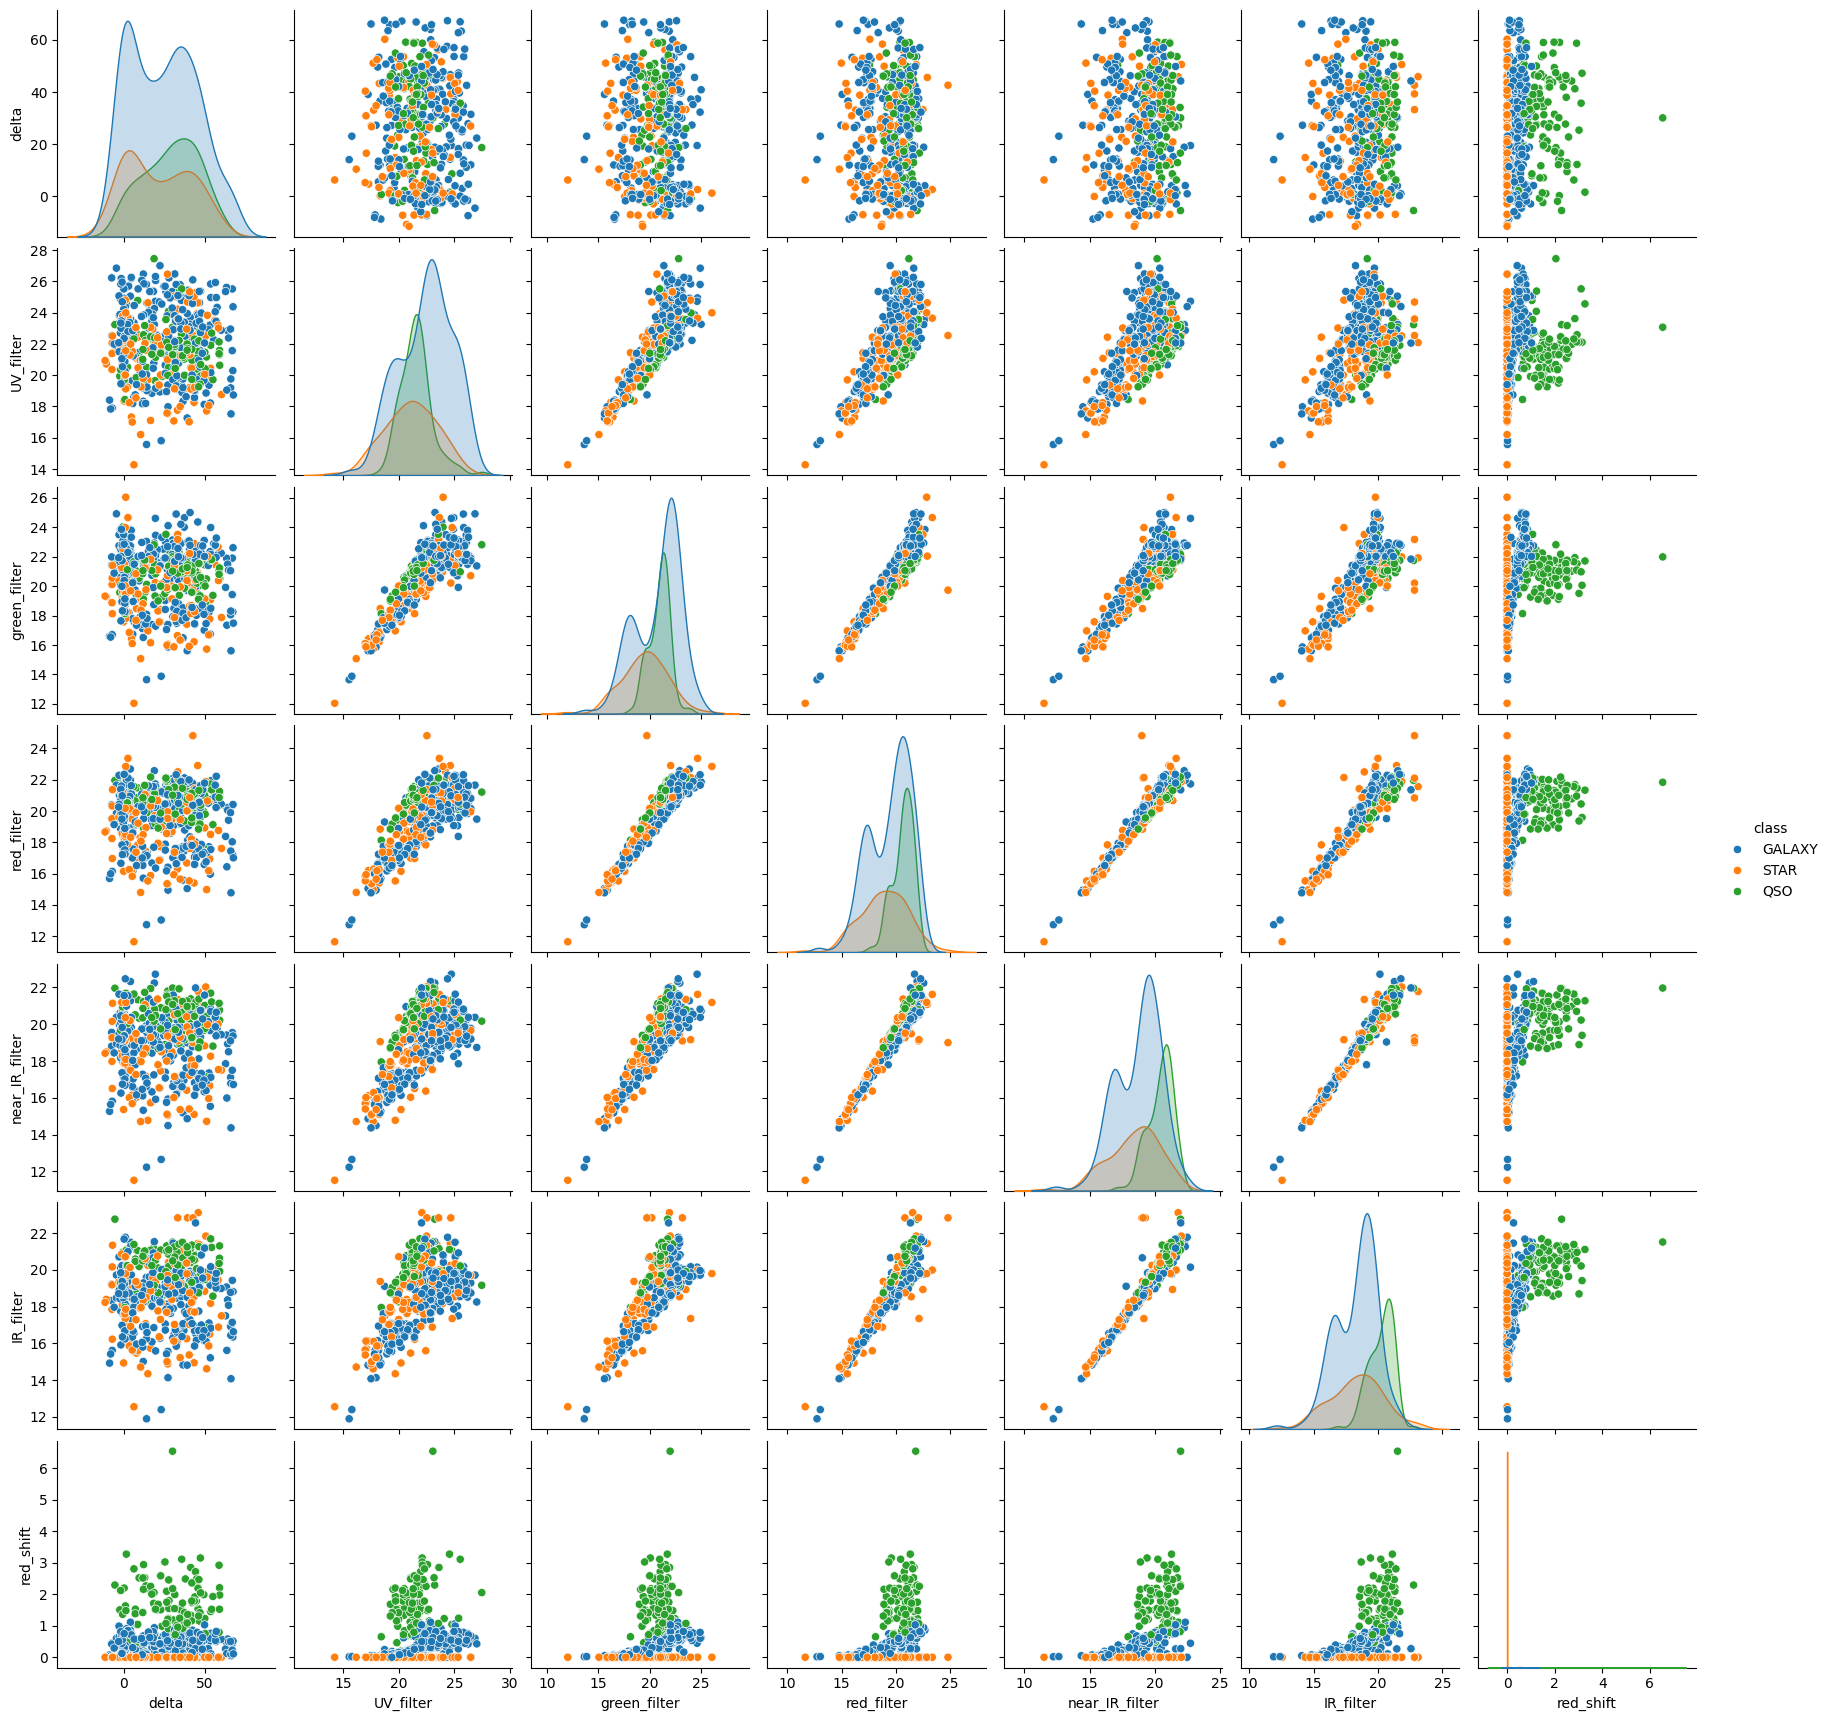

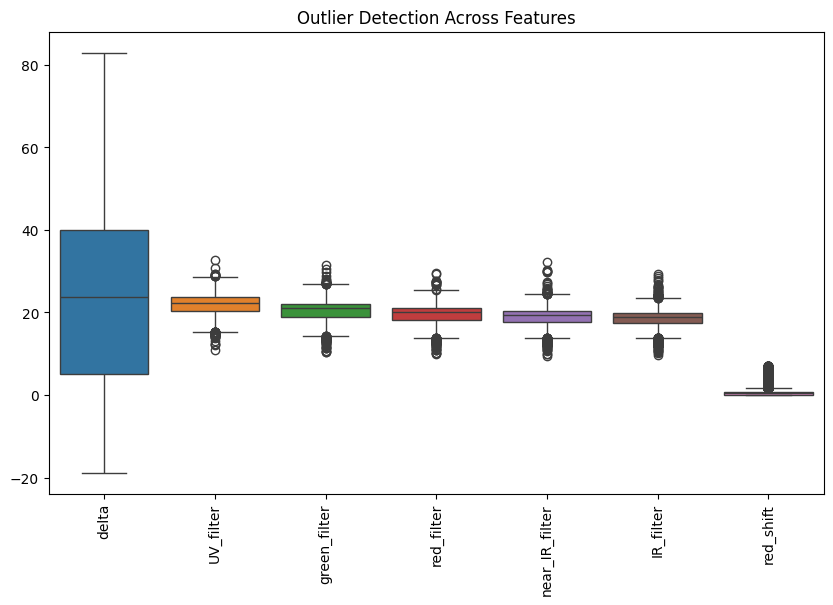

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.countplot(x=y)
plt.title("Distribution of Celestial Object Classes")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()


plt.figure(figsize=(10,8))
sns.heatmap(X.corr(), cmap='coolwarm')
plt.title("Correlation Between Spectral Features")
plt.show()


plt.figure(figsize=(7,5))
sns.boxplot(x=y, y=X['red_shift'])
plt.title("Redshift Distribution by Class")
plt.xlabel("Class")
plt.ylabel("Redshift")
plt.show()

sample_df = df.sample(500)

sns.pairplot(sample_df, hue='class')
plt.show()

plt.figure(figsize=(10,6))
sns.boxplot(data=X)
plt.xticks(rotation=90)
plt.title("Outlier Detection Across Features")
plt.show()

In [41]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

le = LabelEncoder()
y_encoded = le.fit_transform(y)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

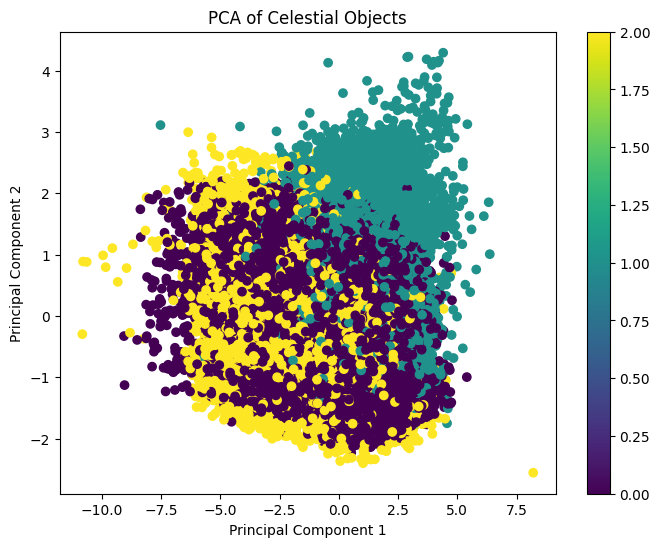

In [42]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
scatter = plt.scatter(X_pca[:,0], X_pca[:,1], c=y_encoded)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA of Celestial Objects")
plt.colorbar(scatter)
plt.show()

In [43]:
print("Explained Variance Ratio:", pca.explained_variance_ratio_)
print("Total Variance Explained:", np.sum(pca.explained_variance_ratio_))

Explained Variance Ratio: [0.64258534 0.14556895]
Total Variance Explained: 0.7881542915976774


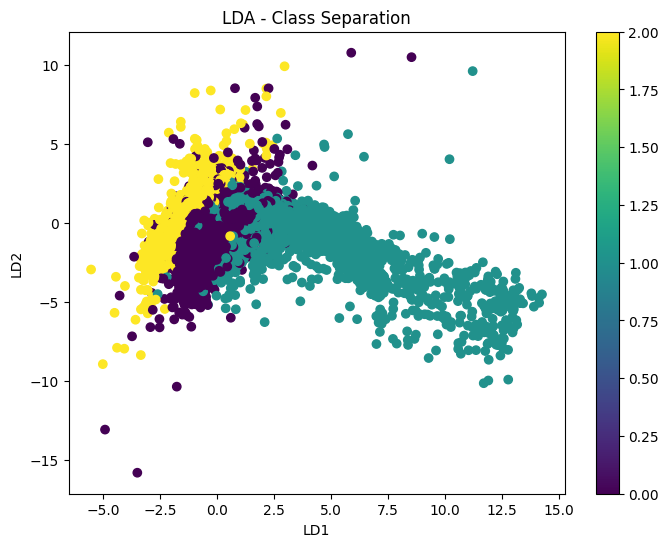

In [44]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = LinearDiscriminantAnalysis()
X_lda = lda.fit_transform(X_scaled, y_encoded)

plt.figure(figsize=(8,6))
scatter = plt.scatter(X_lda[:,0], X_lda[:,1], c=y_encoded)
plt.title("LDA - Class Separation")
plt.xlabel("LD1")
plt.ylabel("LD2")
plt.colorbar(scatter)
plt.show()

In [45]:
from scipy.stats import zscore

z = np.abs(zscore(X_scaled))
outliers = (z > 3).any(axis=1)

print("Number of outliers:", np.sum(outliers))

Number of outliers: 2178


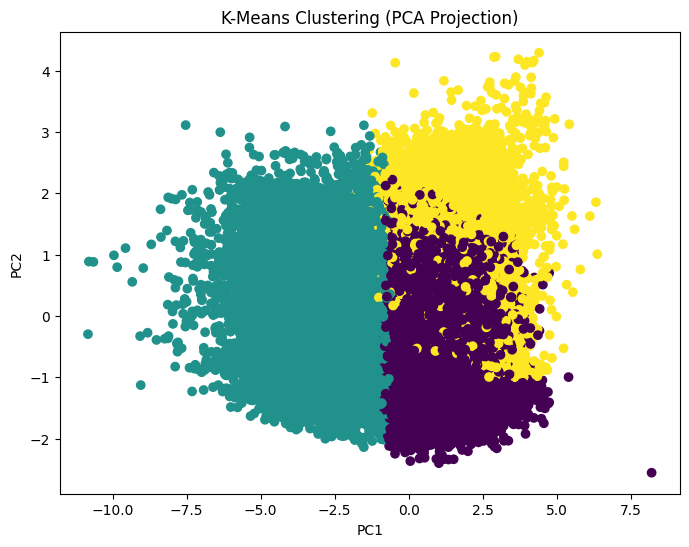

In [46]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters)
plt.title("K-Means Clustering (PCA Projection)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [47]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

print("Accuracy:", model.score(X_test, y_test))

Accuracy: 0.9537
